# Day 11 - Private-World Generalization

?? public-test ??????????????????????????

?? notebook ????????????????????????????????????

In [1]:
import importlib
import sys
from pathlib import Path

import pandas as pd
from IPython.display import display

ROOT = Path.cwd()
while not (ROOT / "pyproject.toml").exists() and ROOT.parent != ROOT:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "notebooks" / "tutorials"))

tu = importlib.import_module("tutorial_utils")

pd.set_option("display.precision", 4)
OUTPUT_DIR = tu.ensure_output(11)
print("project root:", ROOT)
print("output dir:", OUTPUT_DIR)

project root: D:\Projects\ChemWorld
output dir: D:\Projects\ChemWorld\runs\tutorials\day11


## ????

????????????????????????????????????????????????????????????????

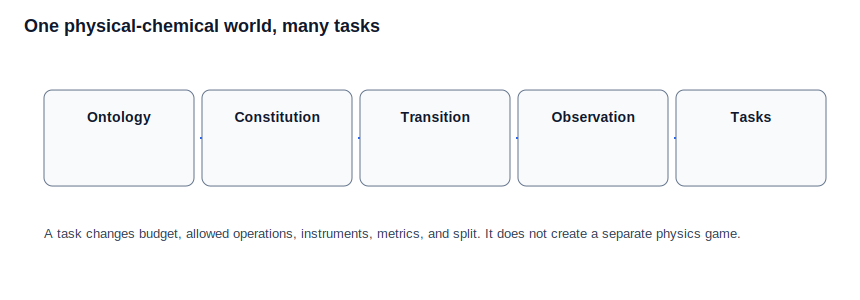

In [2]:
tu.display_tutorial_header(
    day=11,
    title='Private-World Generalization',
    subtitle='?? public-test ??????????????????????????',
    focus=[
        'private-eval split',
        'generalization gap',
        'overfitting diagnosis',
        'robust strategy',
    ],
    deliverables=[
        '?? public/private gap ?',
        '???????',
        '???????',
    ],
    project_link='?? leaderboard ??????? hidden worlds???????????????',
)
tu.display_course_map(11)
display(tu.world_law_svg())


In [3]:
tu.display_api_card()

In [4]:
tu.display_student_checkpoint(
    11,
    [
        "one public/private comparison table",
        "one gap chart",
        "one overfitting diagnosis",
    ],
)

In [5]:
from chemworld.eval.metrics import evaluate_records

strategies = {
    "public_best": {
        "temperature": 75.0,
        "time": 0.50,
        "initial_concentration": 0.35,
        "stirring_speed": 650.0,
        "catalyst": 1,
        "solvent": 1,
    },
    "robust_low_risk": {
        "temperature": 65.0,
        "time": 0.75,
        "initial_concentration": 0.25,
        "stirring_speed": 600.0,
        "catalyst": 1,
        "solvent": 1,
    },
    "fast_high_heat": {
        "temperature": 115.0,
        "time": 0.30,
        "initial_concentration": 0.45,
        "stirring_speed": 850.0,
        "catalyst": 3,
        "solvent": 2,
    },
}
rows = []
for name, recipe in strategies.items():
    for split in ["public-test", "private-eval"]:
        for seed in range(5):
            records = tu.write_recipe_trajectory(
                recipe,
                OUTPUT_DIR / f"{name}_{split}_seed{seed}.jsonl",
                split=split,
                seed=seed,
                agent_name=f"generalization_{name}",
            )
            result = evaluate_records(records).to_dict()
            rows.append({"strategy": name, "split": split, "seed": seed, **result})
gen_df = pd.DataFrame(rows)
summary = gen_df.groupby(["strategy", "split"], as_index=False).agg(
    mean_total=("total_score", "mean"),
    std_total=("total_score", "std"),
    mean_risk=("mean_safety_risk", "mean"),
)
display(summary)

,strategy,split,mean_total,std_total,mean_risk
0,fast_high_heat,private-eval,0.3110,0.1189,0.1336
1,fast_high_heat,public-test,0.1963,0.1167,0.1339
2,public_best,private-eval,0.3329,0.0561,0.0782
3,public_best,public-test,0.3855,0.0759,0.0781
4,robust_low_risk,private-eval,0.3435,0.0577,0.0704
5,robust_low_risk,public-test,0.3941,0.0803,0.0704


split,strategy,private-eval,public-test,public_private_gap
0,robust_low_risk,0.3435,0.3941,0.0506
1,public_best,0.3329,0.3855,0.0526
2,fast_high_heat,0.3110,0.1963,-0.1147


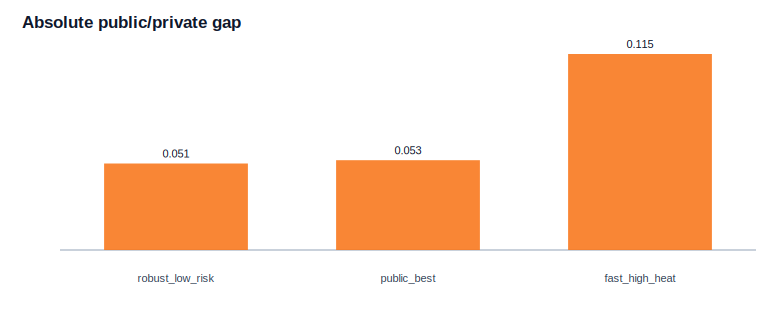

In [6]:
wide = summary.pivot(index="strategy", columns="split", values="mean_total").reset_index()
wide["public_private_gap"] = wide["public-test"] - wide["private-eval"]
wide = wide.sort_values("private-eval", ascending=False).reset_index(drop=True)
display(wide)
display(
    tu.bar_svg(
        wide["strategy"].tolist(),
        wide["public_private_gap"].astype(float).abs().tolist(),
        title="Absolute public/private gap",
        color="#f97316",
    )
)

In [7]:
diagnosis = {
    "small_gap": "Likely robust within this mechanism family.",
    "large_positive_gap": "May be overfit to public-test conditions.",
    "large_negative_gap": "Private placeholder happened to be easier; do not overclaim.",
    "recommended_next_step": ("Trade a little public score for lower risk and lower variance."),
}
tu.show_json_panel("Generalization diagnosis guide", diagnosis)

## Exit Ticket

???????????????????????????

In [8]:
tu.display_reflection_box(["gap ??????????????????", "?????????? private eval?"])